In [ ]:
from keras.models import Model, Sequential
from keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from keras.callbacks import EarlyStopping
from keras.layers.core import SpatialDropout2D
from keras import backend as K
from keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings

filterwarnings('ignore')
np.random.seed(123)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
import re
numbers = re.compile(r'(\d+)')
def numericalSort(value):
    parts = numbers.split(value)
    parts[1::2] = map(int, parts[1::2])
    return parts

In [ ]:
BASEPATH = "../input/siim-isic-melanoma-classification"
df_train_full = pd.read_csv(os.path.join(BASEPATH, 'train.csv'))
df_test  = pd.read_csv(os.path.join(BASEPATH, 'test.csv'))
df_sub   = pd.read_csv(os.path.join(BASEPATH, 'sample_submission.csv'))

In [ ]:
train_path = '../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train'
test_path = '../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test'

In [ ]:
df_test.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge
0,ISIC_0052060,IP_3579794,male,70.0,NaN
1,ISIC_0052349,IP_7782715,male,40.0,lower extremity
2,ISIC_0058510,IP_7960270,female,55.0,torso
3,ISIC_0073313,IP_6375035,female,50.0,torso
4,ISIC_0073502,IP_0589375,female,45.0,lower extremity


In [ ]:
df_train_full.head()
df_train_full.tail()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
33121,ISIC_9999134,IP_6526534,male,50.0,torso,unknown,benign,0
33122,ISIC_9999320,IP_3650745,male,65.0,torso,unknown,benign,0
33123,ISIC_9999515,IP_2026598,male,20.0,lower extremity,unknown,benign,0
33124,ISIC_9999666,IP_7702038,male,50.0,lower extremity,unknown,benign,0
33125,ISIC_9999806,IP_0046310,male,45.0,torso,nevus,benign,0


In [ ]:
df_train_full.tail()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
33121,ISIC_9999134,IP_6526534,male,50.0,torso,unknown,benign,0
33122,ISIC_9999320,IP_3650745,male,65.0,torso,unknown,benign,0
33123,ISIC_9999515,IP_2026598,male,20.0,lower extremity,unknown,benign,0
33124,ISIC_9999666,IP_7702038,male,50.0,lower extremity,unknown,benign,0
33125,ISIC_9999806,IP_0046310,male,45.0,torso,nevus,benign,0


In [ ]:
df_train_full['target'].sum()

584

In [ ]:
df_train_full['target'].count()

33126

In [ ]:
df_train_full[df_train_full.target==0].count()

image_name                       32542
patient_id                       32542
sex                              32477
age_approx                       32474
anatom_site_general_challenge    32024
diagnosis                        32542
benign_malignant                 32542
target                           32542
dtype: int64

In [ ]:
df_train_full[df_train_full.target==1].count()

image_name                       584
patient_id                       584
sex                              584
age_approx                       584
anatom_site_general_challenge    575
diagnosis                        584
benign_malignant                 584
target                           584
dtype: int64

In [ ]:
df_sub.head()

,image_name,target
0,ISIC_0052060,0
1,ISIC_0052349,0
2,ISIC_0058510,0
3,ISIC_0073313,0
4,ISIC_0073502,0


In [ ]:
from PIL import Image
import os, sys
path = "../input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train"
dirs = os.listdir( path )

def resize():
    for item in dirs:
        if os.path.isfile(path+item):
            im = Image.open(path+item)
            f, e = os.path.splitext(path+item)
            imResize = im.resize((200,200), Image.ANTIALIAS)
            imResize.save(f + ' resized.jpg', 'JPEG', quality=90)

resize()

In [ ]:
import pathlib
train_dir = pathlib.Path(train_path)
test_dir = pathlib.Path(test_path)

In [ ]:
image_count1 = len(list(train_dir.glob('*/*.jpg')))
print(image_count1)
image_count2 = len(list(test_dir.glob('*/*.jpg')))
print(image_count2)


2239
118


In [ ]:
batch_size = 32
img_height = 180
img_width = 180

In [ ]:
classes=['pigmented benign keratosis',
 'melanoma',
 'vascular lesion',
 'actinic keratosis',
 'squamous cell carcinoma',
 'basal cell carcinoma',
 'seborrheic keratosis',
 'dermatofibroma',
 'nevus']

In [ ]:
img = Image.open(train_path+'/melanoma/ISIC_0000139.jpg')
print(img.size)

(2816, 2112)


In [ ]:
img_count_train = len(list(train_dir.glob('*/*.jpg')))
img_count_test  = len(list(test_dir.glob('*/*.jpg')))
print('{} train images'.format(img_count_train))
print('{} test  images'.format(img_count_test))

2239 train images
118 test  images


In [ ]:
SEED=123
np.random.seed(SEED)

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


Found 118 files belonging to 9 classes.

9 classes:
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


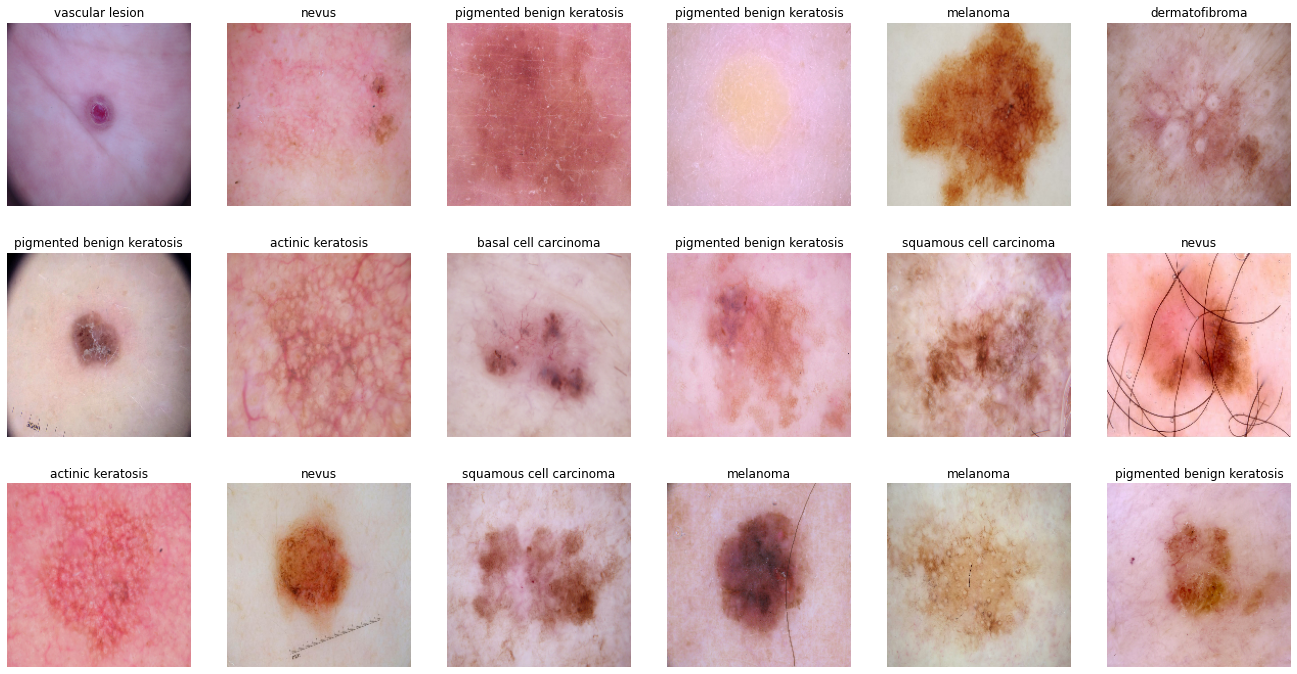

In [ ]:
test_ds  = tf.keras.preprocessing.image_dataset_from_directory(test_dir,image_size=(img_height, img_width), seed=SEED)

class_names = train_ds.class_names
num_classes = len(class_names)
print('\n{} classes:\n{}'.format(num_classes,class_names))

plt.figure(figsize=(23, 12))
for images, labels in train_ds.take(1):
    for i in range(18):
        ax = plt.subplot(3, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0039216885 0.9944443


<h2 style="background-color:White
           ; font-family:newtimeroman; font-size:200%; text-align:left;"> Train the Model with CNN</h2>

![image.png](attachment:7c1a3dfc-2a9e-417c-88f5-03c55455a681.png)


In [ ]:
num_classes = 9

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling_1 (Rescaling)      (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
flatten (Flatten)            (None, 64800)             0         
_________________________________________________________________
dense (Dense)                (None, 64)                4

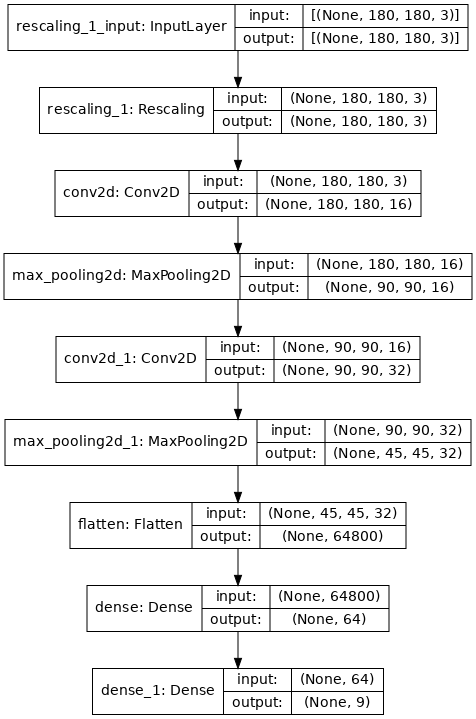

In [ ]:
tf.keras.utils.plot_model(model = model , rankdir="TB", dpi=72, show_shapes=True)

In [ ]:
epochs=100
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/100
56/56 [==============================] - 2s 29ms/step - loss: 0.0998 - accuracy: 0.9420 - val_loss: 2.9012 - val_accuracy: 0.5324
Epoch 2/100
56/56 [==============================] - 2s 28ms/step - loss: 0.0982 - accuracy: 0.9386 - val_loss: 3.1464 - val_accuracy: 0.5369
Epoch 3/100
56/56 [==============================] - 2s 28ms/step - loss: 0.1029 - accuracy: 0.9353 - val_loss: 2.6853 - val_accuracy: 0.5324
Epoch 4/100
56/56 [==============================] - 2s 28ms/step - loss: 0.1051 - accuracy: 0.9353 - val_loss: 2.7213 - val_accuracy: 0.5414
Epoch 5/100
56/56 [==============================] - 2s 28ms/step - loss: 0.1043 - accuracy: 0.9358 - val_loss: 2.8621 - val_accuracy: 0.5414
Epoch 6/100
56/56 [==============================] - 2s 28ms/step - loss: 0.1168 - accuracy: 0.9314 - val_loss: 2.8288 - val_accuracy: 0.5280
Epoch 7/100
56/56 [==============================] - 2s 28ms/step - loss: 0.1379 - accuracy: 0.9235 - val_loss: 3.5606 - val_accuracy: 0.4810
Epoch 

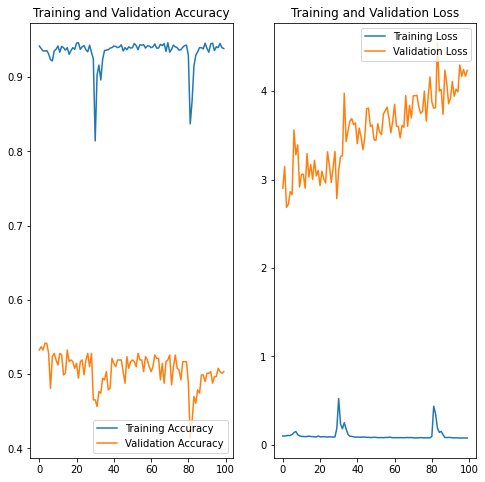

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal",
                                                 input_shape=(img_height,
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

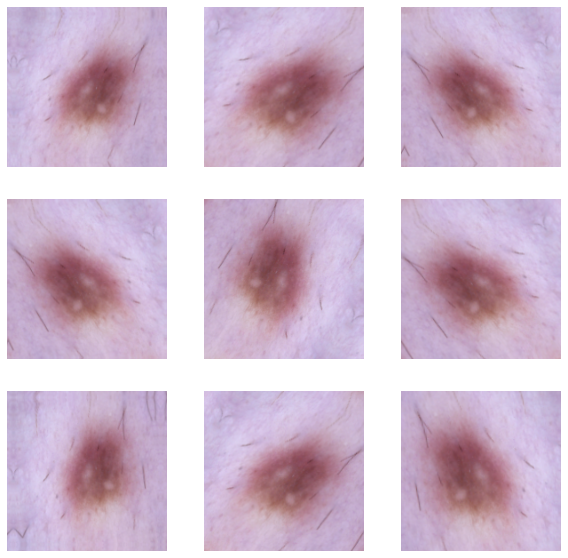

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [ ]:

  aug_model = Sequential([
      data_augmentation,
      layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dense(64, activation='relu'),
      layers.Dense(num_classes)])

In [ ]:
aug_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
aug_model.summary()

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_4 (Sequential)    (None, 180, 180, 3)       0         
_________________________________________________________________
rescaling_9 (Rescaling)      (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_16 (Conv2D)           (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_16 (MaxPooling (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_17 (Conv2D)           (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_17 (MaxPooling (None, 45, 45, 32)        0         
_________________________________________________________________
flatten_8 (Flatten)          (None, 64800)           

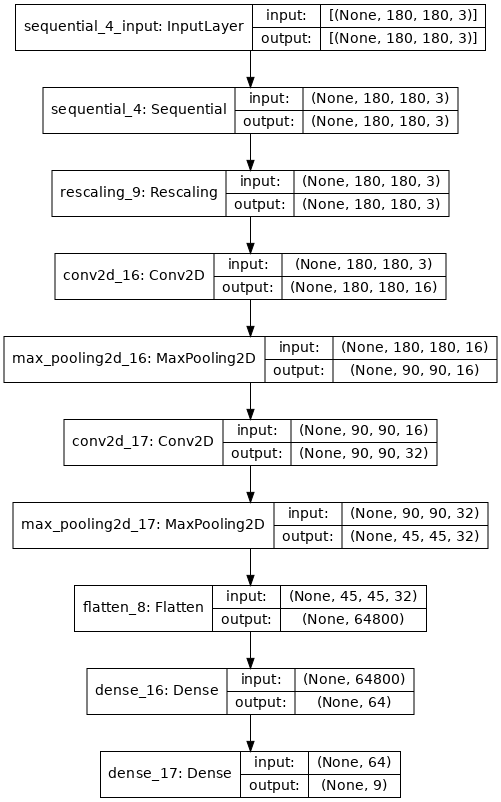

In [ ]:
tf.keras.utils.plot_model(model = aug_model , rankdir="TB", dpi=72, show_shapes=True)

In [ ]:
epochs = 100
history = aug_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/100
56/56 [==============================] - 3s 33ms/step - loss: 2.3587 - accuracy: 0.1832 - val_loss: 1.9832 - val_accuracy: 0.3087
Epoch 2/100
56/56 [==============================] - 2s 29ms/step - loss: 1.9609 - accuracy: 0.2884 - val_loss: 1.9153 - val_accuracy: 0.3110
Epoch 3/100
56/56 [==============================] - 2s 29ms/step - loss: 1.8982 - accuracy: 0.3181 - val_loss: 1.8811 - val_accuracy: 0.3468
Epoch 4/100
56/56 [==============================] - 2s 29ms/step - loss: 1.8054 - accuracy: 0.3572 - val_loss: 1.7185 - val_accuracy: 0.4251
Epoch 5/100
56/56 [==============================] - 2s 29ms/step - loss: 1.6584 - accuracy: 0.4172 - val_loss: 1.6383 - val_accuracy: 0.4004
Epoch 6/100
56/56 [==============================] - 2s 30ms/step - loss: 1.5983 - accuracy: 0.4343 - val_loss: 1.4764 - val_accuracy: 0.4966
Epoch 7/100
56/56 [==============================] - 2s 30ms/step - loss: 1.4846 - accuracy: 0.4903 - val_loss: 1.4968 - val_accuracy: 0.4989
Epoch 

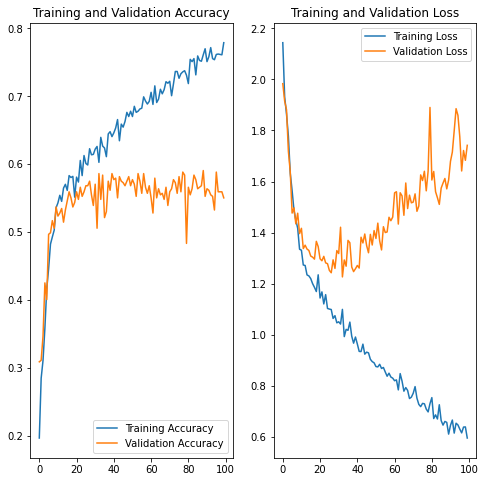

In [ ]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

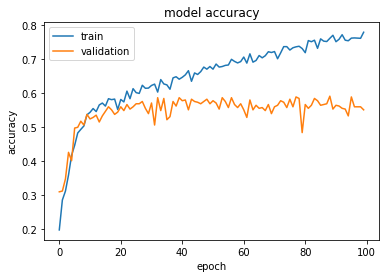

In [ ]:
# Plotting Model accuracy

def plot_history(history):
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()


plot_history(history)